# Causal intervention in the broadcast-sink toy task

This notebook implements the two-layer broadcast task from section 3 in the paper: for each sequence, the model selects

$$
j^*=\arg\max_j \langle x_j,u\rangle,
\qquad
y_i=x_i+\alpha(x_{j^*}R),
$$

so the selected token supplies a content-dependent payload shared by all recipients. After training, we intervene separately in each attention layer while preserving the original attention matrix whenever the value is changed.

The central causal tests are:

1. **Zero sink value:** removes the selected token's payload.
2. **Donor sink value:** replaces it with the selected value from an independent donor sequence.
3. **Donor non-sink value:** patches an ordinary donor value into the same high-attention destination.
4. **Zero random non-sink value:** matched control at a low-attention destination.
5. **Redirect sink attention:** removes the selected destination and renormalizes attention.

For value patching, the notebook verifies the exact local identity

$$
\Delta o_i=A_{ij^*}W_O\!\left(V_{j^*}^{\rm patched}-V_{j^*}^{\rm original}\right),
$$

then measures whether the change remains coherent across recipients and transfers the donor payload at the final model output.

In [ ]:
from pathlib import Path
import math
import random

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch.nn as nn
import torch.nn.functional as F

SEED = 0
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

DMODEL = 64
HEAD_DIM = 64
SEQ_LEN = 32
ALPHA = 1.0

TRAIN_BATCH_SIZE = 1024
TRAIN_STEPS = 30_000
LEARNING_RATE = 5e-4
WEIGHT_DECAY = 1e-4
TRAIN_IF_MISSING = True

CHECKPOINT_PATH = Path("toy_broadcast_causal_checkpoint.pt")

EVAL_BATCHES = 64
EVAL_BATCH_SIZE = 256

sns.set_theme(style="whitegrid", context="talk")

device: cuda


In [ ]:
class OneHead(nn.Module):
    def __init__(self, d=DMODEL, h=HEAD_DIM, length=SEQ_LEN, add_pos=True):
        super().__init__()
        self.add_pos = add_pos
        self.norm = nn.LayerNorm(d)
        self.Wq = nn.Linear(d, h, bias=False)
        self.Wk = nn.Linear(d, h, bias=False)
        self.Wv = nn.Linear(d, h, bias=False)
        self.Wo = nn.Linear(h, d, bias=False)
        self.pos = nn.Parameter(torch.randn(length, d) * 0.02)

    def forward(self, x, ret=False):
        residual = x
        z = x + self.pos.unsqueeze(0) if self.add_pos else x
        z = self.norm(z)

        Q = self.Wq(z)
        K = self.Wk(z)
        V = self.Wv(z)
        scores = Q @ K.transpose(1, 2) / math.sqrt(Q.shape[-1])
        A = torch.softmax(scores, dim=-1)
        output = residual + self.Wo(A @ V)

        cache = {
            "Q": Q,
            "K": K,
            "V": V,
            "scores": scores,
            "A": A,
            "residual": residual,
            "z": z,
        }
        return (output, A, cache) if ret else output


class TwoLayer(nn.Module):
    def __init__(self, d=DMODEL, h=HEAD_DIM, length=SEQ_LEN):
        super().__init__()
        self.l1 = OneHead(d, h, length, add_pos=True)
        self.mlp1 = nn.Sequential(
            nn.LayerNorm(d),
            nn.Linear(d, 4 * d),
            nn.GELU(),
            nn.Linear(4 * d, d),
        )
        self.l2 = OneHead(d, h, length, add_pos=False)
        self.mlp2 = nn.Sequential(
            nn.LayerNorm(d),
            nn.Linear(d, 4 * d),
            nn.GELU(),
            nn.Linear(4 * d, d),
        )

    def forward(self, x, ret=False):
        l1_attn, A1, cache1 = self.l1(x, ret=True)
        h1 = l1_attn + self.mlp1(l1_attn)
        l2_attn, A2, cache2 = self.l2(h1, ret=True)
        output = l2_attn + self.mlp2(l2_attn)

        if not ret:
            return output

        cache = {
            "l1": cache1,
            "l2": cache2,
            "l1_attn": l1_attn,
            "h1": h1,
            "l2_attn": l2_attn,
        }
        return output, (A1, A2), cache


def make_task(x, u, R, alpha=ALPHA):
    j_star = (x @ u).argmax(dim=-1)
    batch = torch.arange(x.shape[0], device=x.device)
    selected_x = x[batch, j_star]
    payload = selected_x @ R
    target = x + alpha * payload.unsqueeze(1)
    return target, j_star, payload

In [ ]:
def train_broadcast_model(steps=TRAIN_STEPS, batch_size=TRAIN_BATCH_SIZE):
    model = TwoLayer().to(device)
    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=LEARNING_RATE,
        weight_decay=WEIGHT_DECAY,
    )

    u = torch.randn(DMODEL, device=device)
    u = u / u.norm().clamp_min(1e-12)

    with torch.no_grad():
        matrix = torch.randn(DMODEL, DMODEL, device=device)
        R, _ = torch.linalg.qr(matrix)
        R = R.contiguous()

    model.train()
    for step in range(1, steps + 1):
        x = torch.randn(batch_size, SEQ_LEN, DMODEL, device=device)
        target, j_star, _ = make_task(x, u, R)
        output, (A1, A2), _ = model(x, ret=True)
        loss = F.mse_loss(output, target)

        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        optimizer.step()

        if step == 1 or step % 5_000 == 0:
            with torch.no_grad():
                batch_idx = torch.arange(batch_size, device=device)
                a1_sink = A1[batch_idx, :, j_star].mean().item()
                a2_sink = A2[batch_idx, :, j_star].mean().item()
            print(
                f"step {step:5d} | loss {loss.item():.4e} | "
                f"A1->j* {a1_sink:.3f} | A2->j* {a2_sink:.3f}"
            )

    return model.eval(), u, R


if CHECKPOINT_PATH.exists():
    checkpoint = torch.load(CHECKPOINT_PATH, map_location=device)
    required = {"model_state_dict", "u", "R"}
    missing = required - set(checkpoint)
    if missing:
        raise KeyError(f"Checkpoint is missing: {sorted(missing)}")

    model = TwoLayer().to(device)
    model.load_state_dict(checkpoint["model_state_dict"])
    model.eval()
    u = checkpoint["u"].to(device)
    R = checkpoint["R"].to(device)
    print(f"Loaded {CHECKPOINT_PATH}")

elif TRAIN_IF_MISSING:
    model, u, R = train_broadcast_model()
    torch.save(
        {
            "model_state_dict": model.state_dict(),
            "u": u.detach().cpu(),
            "R": R.detach().cpu(),
            "seed": SEED,
            "train_steps": TRAIN_STEPS,
            "alpha": ALPHA,
            "task": "argmax-selected rotated payload broadcast",
        },
        CHECKPOINT_PATH,
    )
    print(f"Saved {CHECKPOINT_PATH}")

else:
    raise FileNotFoundError(
        f"Place a checkpoint at {CHECKPOINT_PATH} or set TRAIN_IF_MISSING=True."
    )

step     1 | loss 1.1310e+00 | A1->j* 0.031 | A2->j* 0.031
step  5000 | loss 6.1546e-02 | A1->j* 0.762 | A2->j* 0.959
step 10000 | loss 4.6821e-02 | A1->j* 0.858 | A2->j* 0.968
step 15000 | loss 4.7976e-02 | A1->j* 0.892 | A2->j* 0.967
step 20000 | loss 4.2814e-02 | A1->j* 0.920 | A2->j* 0.973
step 25000 | loss 4.5581e-02 | A1->j* 0.928 | A2->j* 0.970
step 30000 | loss 5.7883e-02 | A1->j* 0.916 | A2->j* 0.959
Saved toy_broadcast_causal_checkpoint.pt


## Intervention mechanics

Each intervention is applied to one layer at a time. Layer-1 interventions are propagated through the first MLP and the complete second block; layer-2 interventions are propagated through the final MLP. Thus, `local_delta` tests the exact attention algebra, while `final_delta` tests whether the causal effect survives the rest of the network.

In [ ]:
INTERVENTIONS = [
    "Baseline",
    "Zero sink value",
    "Donor sink value",
    "Donor non-sink value",
    "Zero random non-sink value",
    "Redirect sink attention",
]


def batch_gather(sequence, indices):
    batch = torch.arange(sequence.shape[0], device=sequence.device)
    return sequence[batch, indices]


def batch_scatter(sequence, indices, values):
    result = sequence.clone()
    batch = torch.arange(sequence.shape[0], device=sequence.device)
    result[batch, indices] = values
    return result


def choose_non_sink(j_star, length=SEQ_LEN):
    # Deterministic and guaranteed to differ from j*.
    return (j_star + 1) % length


def modify_attention_inputs(cache, donor_cache, j_star, donor_j_star, intervention):
    A = cache["A"]
    V = cache["V"]
    A_new = A
    V_new = V
    patched_index = j_star

    if intervention == "Baseline":
        pass

    elif intervention == "Zero sink value":
        V_new = batch_scatter(V, j_star, torch.zeros_like(batch_gather(V, j_star)))

    elif intervention == "Donor sink value":
        donor_value = batch_gather(donor_cache["V"], donor_j_star)
        V_new = batch_scatter(V, j_star, donor_value)

    elif intervention == "Donor non-sink value":
        donor_non_sink = choose_non_sink(donor_j_star)
        donor_value = batch_gather(donor_cache["V"], donor_non_sink)
        V_new = batch_scatter(V, j_star, donor_value)

    elif intervention == "Zero random non-sink value":
        patched_index = choose_non_sink(j_star)
        V_new = batch_scatter(
            V,
            patched_index,
            torch.zeros_like(batch_gather(V, patched_index)),
        )

    elif intervention == "Redirect sink attention":
        A_new = A.clone()
        batch = torch.arange(A.shape[0], device=A.device)
        A_new[batch, :, j_star] = 0.0
        A_new = A_new / A_new.sum(dim=-1, keepdim=True).clamp_min(1e-12)

    else:
        raise ValueError(f"Unknown intervention: {intervention}")

    return A_new, V_new, patched_index


def recompute_head(head, cache, A, V):
    return cache["residual"] + head.Wo(A @ V)


@torch.no_grad()
def intervene_layer(model, x, donor_x, layer, intervention, j_star, donor_j_star):
    baseline, _, base_cache = model(x, ret=True)
    donor_output, _, donor_cache = model(donor_x, ret=True)
    del donor_output

    head = model.l1 if layer == "L1" else model.l2
    cache = base_cache[layer.lower()]
    donor_layer_cache = donor_cache[layer.lower()]

    A_new, V_new, patched_index = modify_attention_inputs(
        cache,
        donor_layer_cache,
        j_star,
        donor_j_star,
        intervention,
    )

    local_baseline = recompute_head(head, cache, cache["A"], cache["V"])
    local_intervened = recompute_head(head, cache, A_new, V_new)
    local_delta = local_intervened - local_baseline

    # Exact local prediction, including the attention-rerouting case.
    predicted_local_delta = head.Wo(A_new @ V_new - cache["A"] @ cache["V"])
    torch.testing.assert_close(local_delta, predicted_local_delta, rtol=1e-4, atol=1e-5)

    if layer == "L1":
        h1 = local_intervened + model.mlp1(local_intervened)
        l2_attn = model.l2(h1)
        final = l2_attn + model.mlp2(l2_attn)
    elif layer == "L2":
        final = local_intervened + model.mlp2(local_intervened)
    else:
        raise ValueError("layer must be 'L1' or 'L2'")

    torch.testing.assert_close(
        recompute_head(head, cache, cache["A"], cache["V"]),
        base_cache["l1_attn" if layer == "L1" else "l2_attn"],
        rtol=1e-4,
        atol=1e-5,
    )

    return {
        "baseline": baseline,
        "final": final,
        "local_delta": local_delta,
        "predicted_local_delta": predicted_local_delta,
        "A": cache["A"],
        "V": cache["V"],
        "patched_index": patched_index,
        "donor_cache": donor_layer_cache,
    }

In [ ]:
def recipient_mask(j_star, length=SEQ_LEN):
    positions = torch.arange(length, device=j_star.device).unsqueeze(0)
    return positions != j_star.unsqueeze(1)


def masked_token_rms(tensor, mask):
    selected = tensor[mask]
    return selected.square().mean().sqrt().item()


def mean_recipient_vector(tensor, mask):
    weights = mask.unsqueeze(-1).to(tensor.dtype)
    return (tensor * weights).sum(dim=1) / weights.sum(dim=1).clamp_min(1.0)


def common_energy_fraction(tensor, mask):
    # Energy explained by the component shared across recipient tokens.
    weights = mask.unsqueeze(-1).to(tensor.dtype)
    mean = mean_recipient_vector(tensor, mask)
    shared_energy = (mean.square().sum(dim=-1) * weights.sum(dim=1).squeeze(-1))
    total_energy = (tensor.square() * weights).sum(dim=(1, 2))
    valid = total_energy > 1e-12
    if not valid.any():
        return float("nan")
    return (shared_energy[valid] / total_energy[valid]).mean().item()


def mean_cosine(a, b):
    valid = (a.norm(dim=-1) > 1e-10) & (b.norm(dim=-1) > 1e-10)
    if not valid.any():
        return float("nan")
    return F.cosine_similarity(a[valid], b[valid], dim=-1).mean().item()


def relative_error(actual, predicted):
    numerator = (actual - predicted).flatten(1).norm(dim=-1)
    denominator = predicted.flatten(1).norm(dim=-1).clamp_min(1e-12)
    return (numerator / denominator).mean().item()


@torch.no_grad()
def evaluate_broadcast_interventions(
    model,
    u,
    R,
    n_batches=EVAL_BATCHES,
    batch_size=EVAL_BATCH_SIZE,
):
    result_rows = []
    routing_rows = []
    model.eval()

    for batch_id in range(n_batches):
        x = torch.randn(batch_size, SEQ_LEN, DMODEL, device=device)
        donor_x = torch.randn(batch_size, SEQ_LEN, DMODEL, device=device)

        target, j_star, payload = make_task(x, u, R)
        _, donor_j_star, donor_payload = make_task(donor_x, u, R)
        donor_target = x + ALPHA * donor_payload.unsqueeze(1)
        no_payload_target = x
        recipients = recipient_mask(j_star)
        desired_transfer = ALPHA * (donor_payload - payload)

        baseline, (A1, A2), cache = model(x, ret=True)

        for layer, A, layer_cache, head in [
            ("L1", A1, cache["l1"], model.l1),
            ("L2", A2, cache["l2"], model.l2),
        ]:
            batch = torch.arange(batch_size, device=device)
            selected_attention = A[batch, :, j_star]
            column_mass = A.mean(dim=1)
            predicted_sink = column_mass.argmax(dim=-1)
            projected_values = head.Wo(layer_cache["V"])
            selected_projected = batch_gather(projected_values, j_star)

            nonsink = recipient_mask(j_star)
            non_sink_norm = projected_values.norm(dim=-1)[nonsink].mean().item()

            routing_rows.append(
                {
                    "batch": batch_id,
                    "layer": layer,
                    "sink_match": (predicted_sink == j_star).float().mean().item(),
                    "attention_to_selected": selected_attention.mean().item(),
                    "selected_projected_value_norm": selected_projected.norm(dim=-1).mean().item(),
                    "non_sink_projected_value_norm": non_sink_norm,
                }
            )

            for intervention in INTERVENTIONS:
                out = intervene_layer(
                    model,
                    x,
                    donor_x,
                    layer,
                    intervention,
                    j_star,
                    donor_j_star,
                )
                final_delta = out["final"] - out["baseline"]
                local_delta = out["local_delta"]
                predicted = out["predicted_local_delta"]
                mean_final_change = mean_recipient_vector(final_delta, recipients)

                result_rows.append(
                    {
                        "batch": batch_id,
                        "layer": layer,
                        "intervention": intervention,
                        "task_mse": F.mse_loss(out["final"], target).item(),
                        "no_payload_mse": F.mse_loss(out["final"], no_payload_target).item(),
                        "donor_target_mse": F.mse_loss(out["final"], donor_target).item(),
                        "final_delta_rms_recipients": masked_token_rms(final_delta, recipients),
                        "local_delta_rms_recipients": masked_token_rms(local_delta, recipients),
                        "recipient_common_energy": common_energy_fraction(final_delta, recipients),
                        "local_prediction_cosine": mean_cosine(
                            local_delta.flatten(1), predicted.flatten(1)
                        ),
                        "local_prediction_relative_error": relative_error(local_delta, predicted),
                        "donor_payload_transfer_cosine": (
                            mean_cosine(mean_final_change, desired_transfer)
                            if intervention == "Donor sink value" else float("nan")
                        ),
                        "donor_target_improvement": (
                            F.mse_loss(baseline, donor_target).item()
                            - F.mse_loss(out["final"], donor_target).item()
                            if intervention == "Donor sink value" else float("nan")
                        ),
                    }
                )

    return pd.DataFrame(result_rows), pd.DataFrame(routing_rows)


results, routing = evaluate_broadcast_interventions(model, u, R)

summary = (
    results.groupby(["layer", "intervention"], sort=False)
    .agg(
        task_mse_mean=("task_mse", "mean"),
        task_mse_sem=("task_mse", "sem"),
        no_payload_mse_mean=("no_payload_mse", "mean"),
        donor_target_mse_mean=("donor_target_mse", "mean"),
        final_delta_rms_mean=("final_delta_rms_recipients", "mean"),
        final_delta_rms_sem=("final_delta_rms_recipients", "sem"),
        local_delta_rms_mean=("local_delta_rms_recipients", "mean"),
        common_energy_mean=("recipient_common_energy", "mean"),
        local_prediction_cosine_mean=("local_prediction_cosine", "mean"),
        local_prediction_relative_error_mean=("local_prediction_relative_error", "mean"),
        donor_payload_transfer_cosine_mean=("donor_payload_transfer_cosine", "mean"),
        donor_target_improvement_mean=("donor_target_improvement", "mean"),
    )
    .reset_index()
)

routing_summary = (
    routing.groupby("layer", sort=False)
    .agg(
        sink_match_mean=("sink_match", "mean"),
        sink_match_sem=("sink_match", "sem"),
        attention_to_selected_mean=("attention_to_selected", "mean"),
        attention_to_selected_sem=("attention_to_selected", "sem"),
        selected_projected_value_norm_mean=("selected_projected_value_norm", "mean"),
        non_sink_projected_value_norm_mean=("non_sink_projected_value_norm", "mean"),
    )
    .reset_index()
)

display(summary)
display(routing_summary)

,layer,intervention,task_mse_mean,task_mse_sem,no_payload_mse_mean,donor_target_mse_mean,final_delta_rms_mean,final_delta_rms_sem,local_delta_rms_mean,common_energy_mean,local_prediction_cosine_mean,local_prediction_relative_error_mean,donor_payload_transfer_cosine_mean,donor_target_improvement_mean
0,L1,Baseline,0.048055,0.001223,0.997201,1.913929,0.000000,0.000000,0.000000,NaN,NaN,0.000000e+00,NaN,NaN
1,L1,Zero sink value,4.365217,0.010922,5.677983,6.884852,2.065344,0.002702,2.078046,0.906642,1.000000,2.260122e-07,NaN,NaN
2,L1,Donor sink value,0.102084,0.001769,0.992498,1.868370,0.231676,0.002514,0.421469,0.998052,1.000000,1.922963e-06,0.162401,0.045560
3,L1,Donor non-sink value,0.255393,0.003749,0.909015,1.888350,0.441030,0.003258,0.920227,0.997611,1.000000,9.598856e-07,NaN,NaN
4,L1,Zero random non-sink value,0.054658,0.001903,1.006328,1.923996,0.065178,0.006667,0.055009,0.513872,0.826320,4.214344e-01,NaN,NaN
5,L1,Redirect sink attention,0.588581,0.010881,1.593331,2.539835,0.724814,0.007425,0.732531,0.971140,1.000000,2.248002e-06,NaN,NaN
6,L2,Baseline,0.048055,0.001223,0.997201,1.913929,0.000000,0.000000,0.000000,NaN,NaN,0.000000e+00,NaN,NaN
7,L2,Zero sink value,3.072903,0.002592,2.406892,3.150243,1.724190,0.001178,1.733628,0.999949,1.000000,1.336660e-07,NaN,NaN
8,L2,Donor sink value,1.948880,0.003033,1.107237,0.229851,1.362649,0.001348,1.362625,0.999954,1.000000,3.404604e-07,0.943767,1.684078
9,L2,Donor non-sink value,2.013307,0.003001,1.111963,2.122734,1.386143,0.001378,1.385958,0.999952,1.000000,3.336416e-07,NaN,NaN


,layer,sink_match_mean,sink_match_sem,attention_to_selected_mean,attention_to_selected_sem,selected_projected_value_norm_mean,non_sink_projected_value_norm_mean
0,L1,0.953552,0.001597,0.929005,0.001366,17.533320,17.810312
1,L2,0.978149,0.001075,0.966752,0.000903,14.229015,13.664778


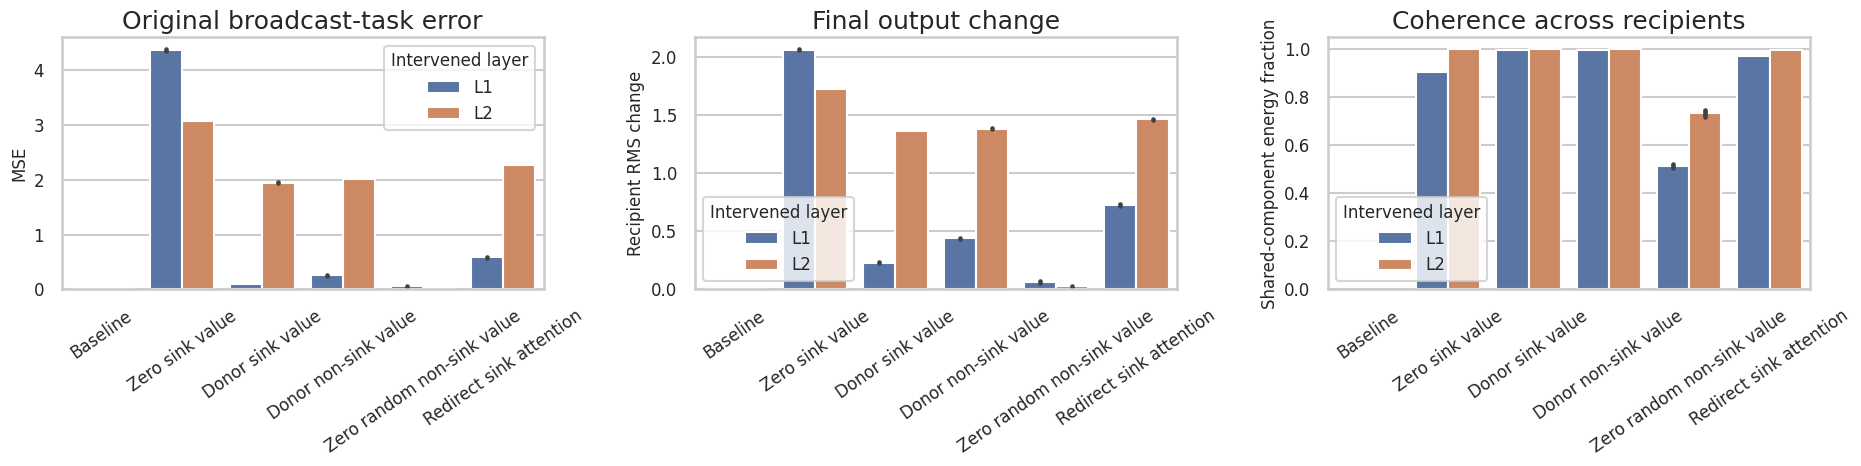

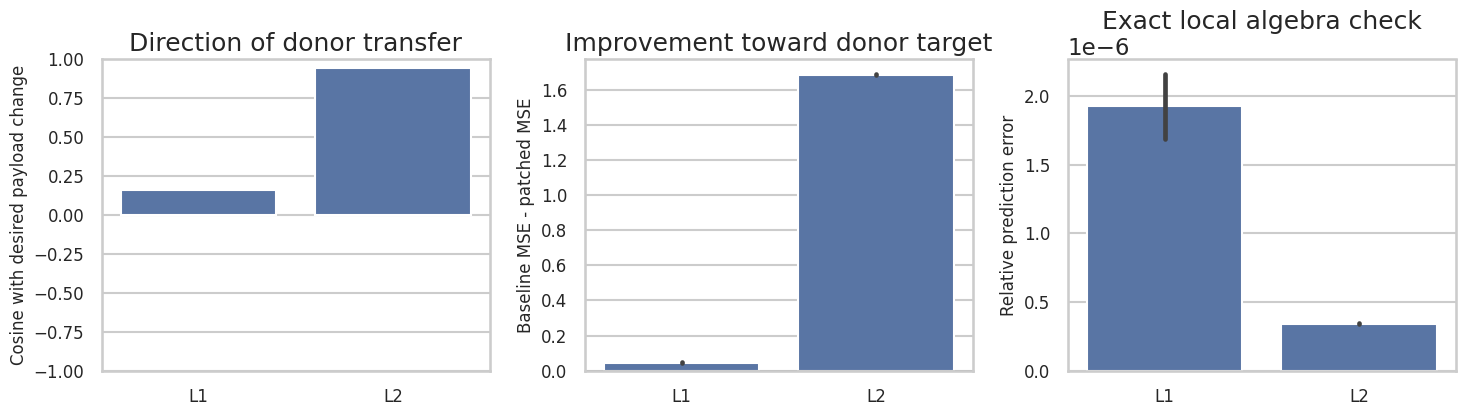

In [ ]:
intervention_order = INTERVENTIONS

fig, axes = plt.subplots(1, 3, figsize=(19, 5))

sns.barplot(
    data=results,
    x="intervention",
    y="task_mse",
    hue="layer",
    order=intervention_order,
    errorbar="se",
    ax=axes[0],
)
axes[0].set_title("Original broadcast-task error")
axes[0].set_xlabel("")
axes[0].set_ylabel("MSE", fontsize=12)
axes[0].tick_params(axis="y", labelsize=12)

sns.barplot(
    data=results,
    x="intervention",
    y="final_delta_rms_recipients",
    hue="layer",
    order=intervention_order,
    errorbar="se",
    ax=axes[1],
)
axes[1].set_title("Final output change")
axes[1].set_xlabel("")
axes[1].set_ylabel("Recipient RMS change", fontsize=12)
axes[1].tick_params(axis="y", labelsize=12)

sns.barplot(
    data=results,
    x="intervention",
    y="recipient_common_energy",
    hue="layer",
    order=intervention_order,
    errorbar="se",
    ax=axes[2],
)
axes[2].set_title("Coherence across recipients")
axes[2].set_xlabel("")
axes[2].set_ylabel("Shared-component energy fraction", fontsize=12)
axes[2].set_ylim(0, 1.05)
axes[2].tick_params(axis="y", labelsize=12)

for ax in axes:
    ax.tick_params(axis="x", rotation=35, labelsize=12)
    handles, labels = ax.get_legend_handles_labels()
    ax.legend(handles, labels, title="Intervened layer", fontsize=12, title_fontsize=12)

plt.tight_layout()
plt.savefig("broadcast_causal_interventions.pdf", bbox_inches="tight")
plt.show()


donor_results = results[results["intervention"] == "Donor sink value"]
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

sns.barplot(
    data=donor_results,
    x="layer",
    y="donor_payload_transfer_cosine",
    errorbar="se",
    ax=axes[0],
)
axes[0].set_title("Direction of donor transfer")
axes[0].set_xlabel("")
axes[0].set_ylabel("Cosine with desired payload change", fontsize=12)
axes[0].set_ylim(-1, 1)
axes[0].tick_params(axis="x", labelsize=12)
axes[0].tick_params(axis="y", labelsize=12)

sns.barplot(
    data=donor_results,
    x="layer",
    y="donor_target_improvement",
    errorbar="se",
    ax=axes[1],
)
axes[1].axhline(0, color="black", linewidth=1)
axes[1].set_title("Improvement toward donor target")
axes[1].set_xlabel("")
axes[1].set_ylabel("Baseline MSE - patched MSE", fontsize=12)
axes[1].tick_params(axis="x", labelsize=12)
axes[1].tick_params(axis="y", labelsize=12)

sns.barplot(
    data=donor_results,
    x="layer",
    y="local_prediction_relative_error",
    errorbar="se",
    ax=axes[2],
)
axes[2].set_title("Exact local algebra check")
axes[2].set_xlabel("")
axes[2].set_ylabel("Relative prediction error", fontsize=12)
axes[2].tick_params(axis="x", labelsize=12)
axes[2].tick_params(axis="y", labelsize=12)

plt.tight_layout()
plt.savefig("broadcast_donor_transfer.pdf", bbox_inches="tight")
plt.show()